# Lecture 2 - Importance Sampling and Random Walks
## Exercise 2.1
Compute the following 1D integral via Monte Carlo 
$$
I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1
$$
1. sampling a uniform distribution in $[0,1]$
2. using importance sampling (i.e. sampling a non-uniform probability in $[0,1]$)

Show a picture of both your estimations of $I$  and their uncertainties with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$.

## Exercise 2.1 - Solution
### Monte Carlo integrals calculation
Monte Carlo integration uses random sampling to approximate the mean value of a function.

The main idea is based on the observation that an integral $I = \int_{a}^{b} f(x) dx$ can be seen as the product of the interval length and the average value of the function over that interval. By taking $N$ random variables $x_i$ uniformly distributed in $[a, b]$, the integral is approximated by the arithmetic mean of the function values at these random points
$$I = (b-a) \langle f \rangle_{[a,b]} \cong (b-a) \frac{1}{N} \sum_{i=1}^{N} f(x_i)$$
This approach can be generalized for any probability distribution $p(x)$ where the integral takes the form $I = \int_{\Omega} g(x) p(x) dx$. In this context, $p(x)$ serves as a probability density function that is non-negative and integrates to unity over the domain $\Omega$. The estimator $G_N$ is then defined as the simple average of the function $g(x)$ sampled from the distribution $p(x)$
$$G_N = \frac{1}{N} \sum_{i=1}^{N} g(x_i) \ .$$

Most importantly Monte Carlo integration has a predictable error behavior. Unlike deterministic methods, the error $\varepsilon$ in an MC calculation is a statistical quantity. It is characterized by the standard deviation of the estimator, which scales as
$$
\varepsilon = \frac{\sigma_I}{\sqrt{N}}
$$
Where $\sigma_I$ represents the intrinsic variance of the function, calculated as $\sigma_I^2 = \int_{\Omega} g^2(x) p(x) dx - I^2$. To achieve a specific desired error $\varepsilon$, one can invert this relationship to determine the necessary number of samples, $N = \sigma_I^2 / \varepsilon^2$.

### Importance sampling
While Monte Carlo samples uniformly or according to a pre-defined probability distribution $p(\vec{x})$, importance sampling introduces an auxiliary distribution $d(\vec{x})$ to focus computational effort where the integrand is most significant.

We rewrite the original integral $I = \int g(\vec{x})p(\vec{x})d\vec{x}$ by multiplying and dividing by a new probability density function $d(\vec{x})$. This new distribution must be non-negative for all $\vec{x}$ and must integrate to unity over the domain. The transformed integral becomes
$$
I = \int \left[ \frac{g(\vec{x})p(\vec{x})}{d(\vec{x})} \right] d(\vec{x}) d\vec{x}
$$
The resulting arithmetic mean is
$$
G_N = \frac{1}{N} \sum_{i=1}^{N} \frac{g(\vec{x}_i)p(\vec{x}_i)}{d(\vec{x}_i)}
$$

The goal of selecting a specific $d(\vec{x})$ is to minimize the variance of the estimate, thereby reducing the statistical error. The variance of the integral using this new distribution is defined as 
$$
\text{var}[I]_d = \int \left[ \frac{g(\vec{x})p(\vec{x})}{d(\vec{x})} \right]^2 d(\vec{x}) d\vec{x} - I^2
$$
To find the optimal distribution the method of Lagrange multipliers is used to minimize the integral while subject to the constraint that $d(\vec{x})$ remains normalized. Performing functional differentiation reveals that the ideal sampling distribution $d(\vec{x})$ is directly proportional to the absolute value of the original integrand
$$
d(\vec{x}) = \lambda |g(\vec{x})p(\vec{x})|\ .
$$



In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.gridspec as gridspec


plt.style.use('default')
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

### Implementation

In our implementation we chose the distribution $d(x) = -2x + 2$. This linear decay is effective because it follows the general behavior of the cosine function in the interval $[0, 1]$. By integrating the distribution to find the cumulative function $F(x) = \int_0^x (-2x' + 2) dx' = -x^2 + 2x$ and setting it equal to a uniform random variable $y \in [0, 1]$, the solution for $x$ becomes $x = 1 - \sqrt{1 - y}$. 

In our code we compared the standard Monte Carlo approach, the code samples a uniform variable via rnd.Rannyu() and averages the function values. In the Importance Sampling approach, it samples $x$ via rnd.Line() and evaluates the ratio of the integrand to the probability density, specifically function_cosine(x_sampl)/p_of_x(x_sampl). 

This process reshapes the integral as $I = \displaystyle\int \frac{f(x)}{d(x)} d(x) dx$, and since $d(x)$ is similar to $f(x)$, the resulting ratio is nearly constant. 

Again the data blocking method is used to compute errors. It divides the total $M = 10^5$ throws into $N = 100$ blocks of $L = 10^3$ steps each. For every block, it calculates a partial average, and subsequently, it computes the cumulative average and the statistical uncertainty (the "error of the mean") as a function of the number of blocks used. 

We found that the Importance Sampling method converges significantly faster and produces a much smaller statistical error. This happens because of the weighting of the points where the function is most relevant.

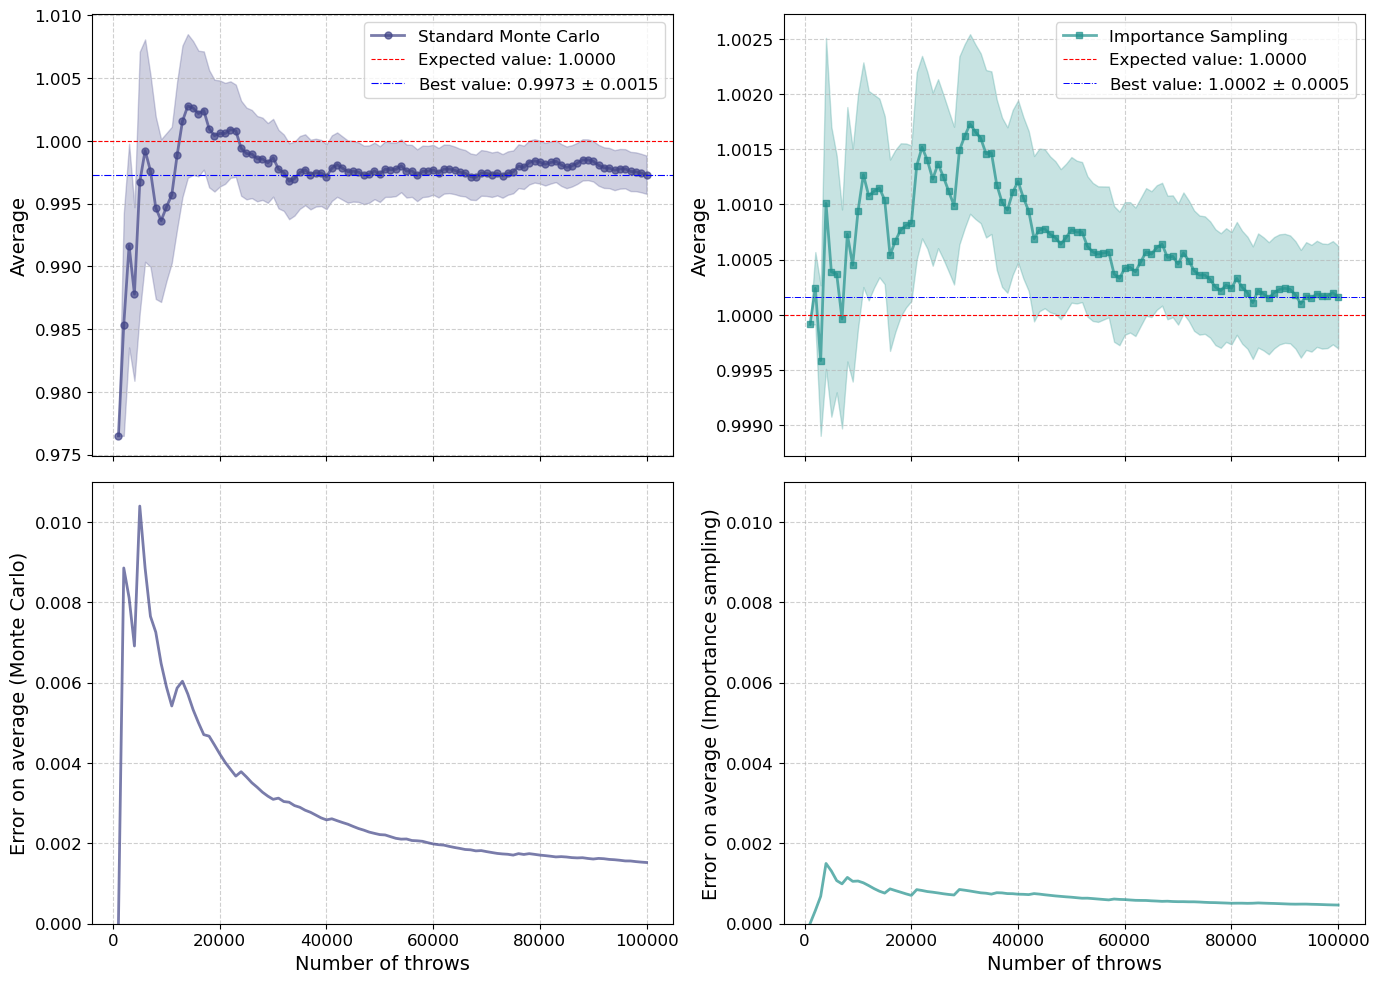

In [7]:
file_std = "Exercise_2_1/output_average.data"
file_imp = "Exercise_2_1/output_impsampling.data"

x1, y1, error1 = np.loadtxt(file_std, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x2, y2, error2 = np.loadtxt(file_imp, usecols=(0, 1, 2), delimiter='\t', unpack=True)

x3, y3 = np.loadtxt(file_std, usecols=(0, 2), delimiter='\t', unpack=True)
x4, y4 = np.loadtxt(file_imp, usecols=(0, 2), delimiter='\t', unpack=True)

viridis = plt.cm.viridis
color_std = viridis(0.2)    
color_is = viridis(0.5)   
ref_color = 'red'
ref_color_2 = 'blue'

fig, axs = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
# -------------------------
axs[0, 0].plot(x1, y1, 'o-', color=color_std, alpha=0.7, markersize=5,label='Standard Monte Carlo')
axs[0, 0].fill_between(x1, y1-error1, y1+error1,
                       color=color_std, alpha=0.25)
axs[0, 0].axhline(y=1, color=ref_color, linestyle='--', linewidth=0.8, label=rf'Expected value: {1:.4f}')
axs[0, 0].axhline(y=y1[99], color=ref_color_2, linestyle='-.', linewidth=0.8,
                 label=rf'Best value: {y1[-1]:.4f} $\pm$ {error1[-1]:.4f}')
axs[0, 0].set_ylabel('Average')
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle='--', alpha=0.6)
axs[0, 0].tick_params(axis='x', labelbottom=False)

# -------------------------
axs[0, 1].plot(x2, y2, 's-', color=color_is, alpha=0.7, markersize=5, label='Importance Sampling')
axs[0, 1].fill_between(x2, y2-error2, y2+error2,
                       color=color_is, alpha=0.25)
axs[0, 1].axhline(y=1, color=ref_color, linestyle='--', linewidth=0.8,label=rf'Expected value: {1:.4f}')
axs[0, 1].axhline(y=y2[-1], color=ref_color_2, linestyle='-.', linewidth=0.7,
                 label=rf'Best value: {y2[-1]:.4f} $\pm$ {error2[-1]:.4f}')
axs[0, 1].set_ylabel('Average')
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle='--', alpha=0.6)
axs[0, 1].tick_params(axis='x', labelbottom=False)

# -------------------------
axs[1, 0].plot(x3, y3, '-', color=color_std, alpha=0.7)
axs[1, 0].set_xlabel('Number of throws')
axs[1, 0].set_ylabel('Error on average (Monte Carlo)')
axs[1, 0].set_ylim([0, 0.011])
axs[1, 0].grid(True, linestyle='--', alpha=0.6)

# -------------------------
axs[1, 1].plot(x4, y4, '-', color=color_is, alpha=0.7)
axs[1, 1].set_xlabel('Number of throws')
axs[1, 1].set_ylabel('Error on average (Importance sampling)')
axs[1, 1].set_ylim([0, 0.011])
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Exercise 2.2
3D Random Walks (RW) on a cubic lattice and in the continuum: Repeat many times (e.g. say $10^4$) the simulation of a random walk in 3D always starting at the origin

1. on a cubic lattice with lattice constant $a=1$; at each discrete time the walker makes a forward or backward step of length equal to $a$ in one of the 3 principal directions of the lattice: $x$, $y$ or $z$
2. in the continuum; at each discrete time the walker makes a step of length equal to $a(=1)$ along a **random direction** obtained by sampling **uniformly** the solid angle: $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$

Show a picture of $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ for both RWs, with their statistical uncertainties, as function of the step $i\in [0,10^2]$.

Suggestion: divide your $M$ throws into a reasonable number of blocks, compute $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ as function of the step $i\in [0,10^2]$ in each block and use these values (for fixed $i$) to obtain the average value and its statistical uncertainty.

Note that you could try to fit both results with a function like $f(N)=k\sqrt{N}$. Do your results indicate a diffusive behavior?

## Exercise 2.2 - Background and solution
A random walks (RW) is a kind of stochastic process, which can be defined as a family $(X_t)_{t \in I}$ of random variables representing information that unfolds over time. These processes can be categorized as discrete-time ($I = \mathbb{N}$) or continuous-time ($I = \mathbb{R}$).

A RW is an example of a Markov process, in which the defining characteristic is the memoryless property: the future state of the system depends only on the current state and not on the sequence of events that preceded it. Mathematically, for a sequence of times $t_1 < t_2 < \dots < t_n$, the conditional probability reads
$$
P_{1|n-1}(x_n, t_n | x_1, t_1; \dots; x_{n-1}, t_{n-1}) = p_{1|1}(x_n, t_n | x_{n-1}, t_{n-1})
$$
A Markov process is characterized by its initial probability distribution $p_1(x, t)$ and its transition probability $p_{1|1}(x_i, t_i | x_{i-1}, t_{i-1})$. This allows the $n$-point joint probability distribution to be expressed as a product of transitions
$$
p_n(x_1, t_1; \dots; x_n, t_n) = p_1(x_1, t_1) \prod_{i=2}^n p_{1|1}(x_i, t_i | x_{i-1}, t_{i-1})
$$
The consistency of these transition probabilities is governed by the Chapman-Kolmogorov equation, which describes how the system evolves from an initial state to a final state through all possible intermediate states
$$
p_{1|1}(x_3, t_3 | x_1, t_1) = \int p_{1|1}(x_3, t_3 | x_2, t_2) p_{1|1}(x_2, t_2 | x_1, t_1) dx_2
$$
In the specific case of a RW on a lattice with spacing $a$, the probability $p_1(na, (s+1)\tau)$ of finding the particle at position $na$ after $s+1$ steps is determined by the sum of probabilities from all possible previous sites $ma$
$$
p_1(na, (s+1)\tau) = \sum_{m=-\infty}^{\infty} p_{1|1}(na, (s+1)\tau | ma, s\tau) p_1(ma, s\tau)
$$
When considering the continuum limit (step length $a \to 0$ and time interval $\tau \to 0$), the discrete master equation converges to the diffusion equation for the probability density $p_1(x,t)$
$$
\frac{\partial p_1(x,t)}{\partial t} = D \frac{\partial^2 p_1(x,t)}{\partial x^2}
$$
Here, the diffusion coefficient is defined as $D = \frac{a^2}{2\tau}$. The solution to this equation for an initial delta distribution $\delta(x)$ is a Gaussian distribution
$$
p_1(x,t) = \frac{1}{\sqrt{4\pi Dt}} e^{-\frac{x^2}{4Dt}}
$$
While the mean displacement $\langle x(t) \rangle$ is zero, the mean squared displacement (variance) grows linearly with time
$$\langle x^2(t) \rangle = 2Dt$$
This behavior predicts that for both discrete and continuous 3D RW, the root mean square (RMS) distance should scale with the number of steps $N$ according to the law $\sqrt{\langle |\vec{r}_N|^2 \rangle} = k\sqrt{N}$, which serves as the primary indicator of diffusive behavior in this exercise.
### Implementation 
#### Discrete RW
The walker is restricted to the vertices of a three-dimensional grid with lattice constant $a$. At each step a direction is picked among the three principal axes ($x, y, z$) by generating a random integer between $0$ and $2$. Then the orientation can be a forward ($+a$) or backward ($-a$). 

#### Continuous RW 
We can move in any direction in the three-dimensional space, provided the step length is exactly $a$. 
Here we have to pay attention in the choice of the direction to have a correct sampling of the solid angle. By sampling $\theta$ uniformly, we would get a higher of points at the poles, because  we are essentially assigning the same number of point to every slice of the sphere regardless of its diameter. To get a real uniform distribution on a sphere, we sampled $\cos(\theta)$ uniformly in the interval $[-1, 1]$.


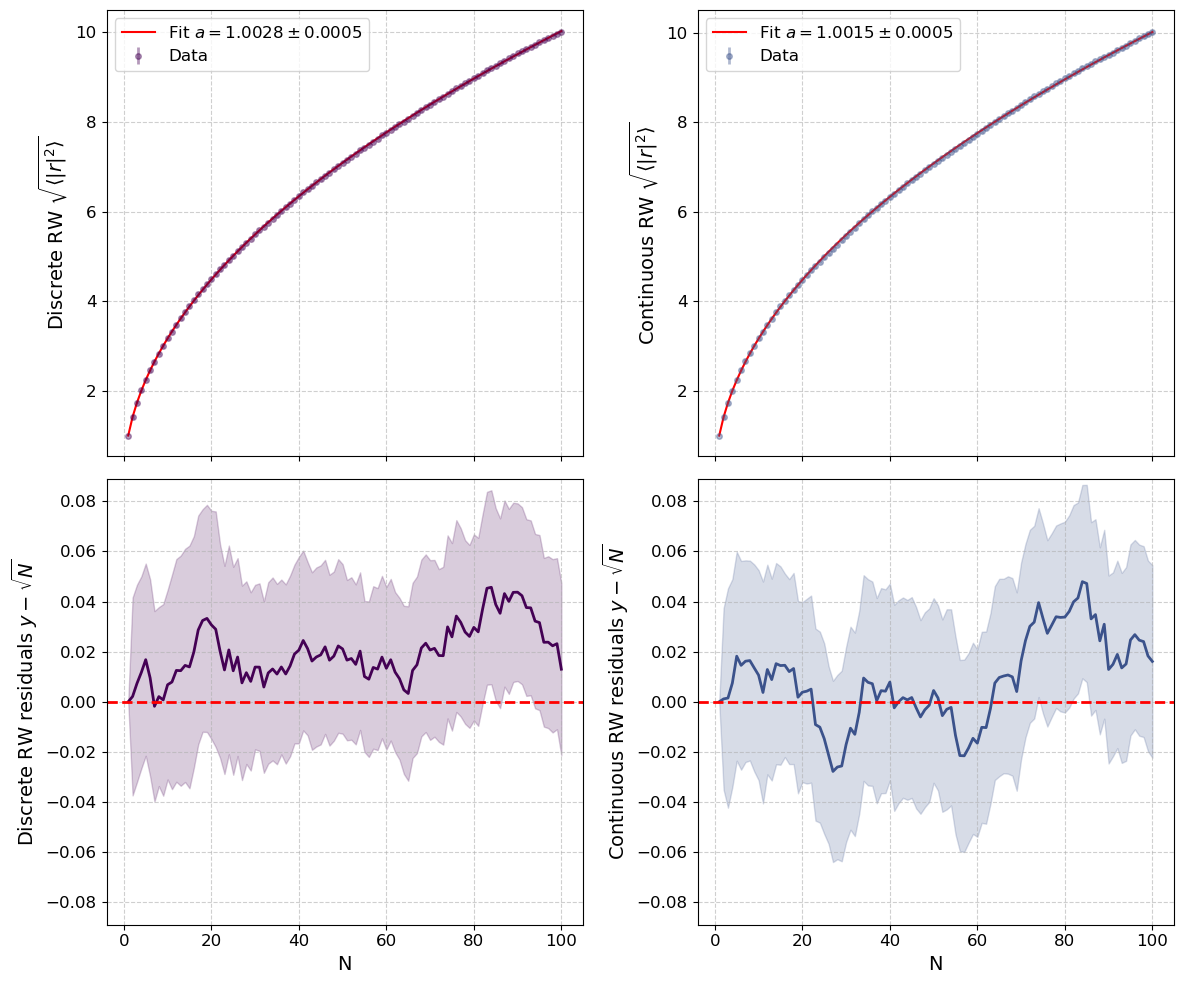

In [25]:
def fit_func(x, k):
    return k * np.sqrt(x)

file_discrete = "Exercise_2_2/output_RW_discrete_1.000000.data"
file_continuous = "Exercise_2_2/output_RW_continuous_1.000000.data"
a_val = 1.0
viridis = plt.cm.viridis(np.linspace(0, 1, 5))
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.25)


x_d, y_d, err_d = np.loadtxt(file_discrete, usecols=(0, 1, 2), delimiter='\t', unpack=True)
popt_d, pcov_d = curve_fit(fit_func, x_d[1:], y_d[1:], sigma=err_d[1:], absolute_sigma=True)
res_d = y_d - a_val * np.sqrt(x_d)

x_c, y_c, err_c = np.loadtxt(file_continuous, usecols=(0, 1, 2), delimiter='\t', unpack=True)
popt_c, pcov_c = curve_fit(fit_func, x_c[1:], y_c[1:], sigma=err_c[1:], absolute_sigma=True)
res_c = y_c - a_val * np.sqrt(x_c)

perr_d = np.sqrt(np.diag(pcov_d)) 
perr_c = np.sqrt(np.diag(pcov_c)) 

axes[0, 0].plot(x_d, fit_func(x_d, *popt_d), 'r-', linewidth=1.5, 
               label=rf'Fit $a={popt_d[0]:.4f} \pm {perr_d[0]:.4f}$')
axes[0, 0].errorbar(x_d, y_d, yerr=err_d, fmt='o', markersize=4, color=viridis[0], alpha=0.4, label='Data')
axes[0, 0].tick_params(axis='x', labelbottom=False)
axes[0, 0].set_ylabel(r'Discrete RW $\sqrt{\langle|r|^2\rangle}$')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)
axes[0, 0].legend()

axes[1, 0].plot(x_d, res_d, color=viridis[0])
axes[1, 0].fill_between(x_d, res_d - err_d, res_d + err_d, color=viridis[0], alpha=0.2)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('N')
axes[1, 0].set_ylim(-0.089,0.089)
axes[1, 0].set_ylabel(r'Discrete RW residuals $y - \sqrt{N}$')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)


axes[0, 1].errorbar(x_c, y_c, yerr=err_c, fmt='o', markersize=4, color=viridis[1], alpha=0.4, label='Data')
axes[0, 1].plot(x_c, fit_func(x_c, *popt_c), 'r-', linewidth=1.5, 
               label=rf'Fit $a={popt_c[0]:.4f} \pm {perr_c[0]:.4f}$')
axes[0, 1].set_ylabel(r'Continuous RW $\sqrt{\langle|r|^2\rangle}$')
axes[0, 1].grid(True, linestyle='--', alpha=0.6)
axes[0, 1].tick_params(axis='x', labelbottom=False)
axes[0, 1].legend()

axes[1, 1].plot(x_c, res_c, color=viridis[1])
axes[1, 1].fill_between(x_c, res_c - err_c, res_c + err_c, color=viridis[1], alpha=0.2)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('N')
axes[1, 1].set_ylim(-0.089,0.089)
axes[1, 1].set_ylabel(r'Continuous RW residuals $y - \sqrt{N}$')
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

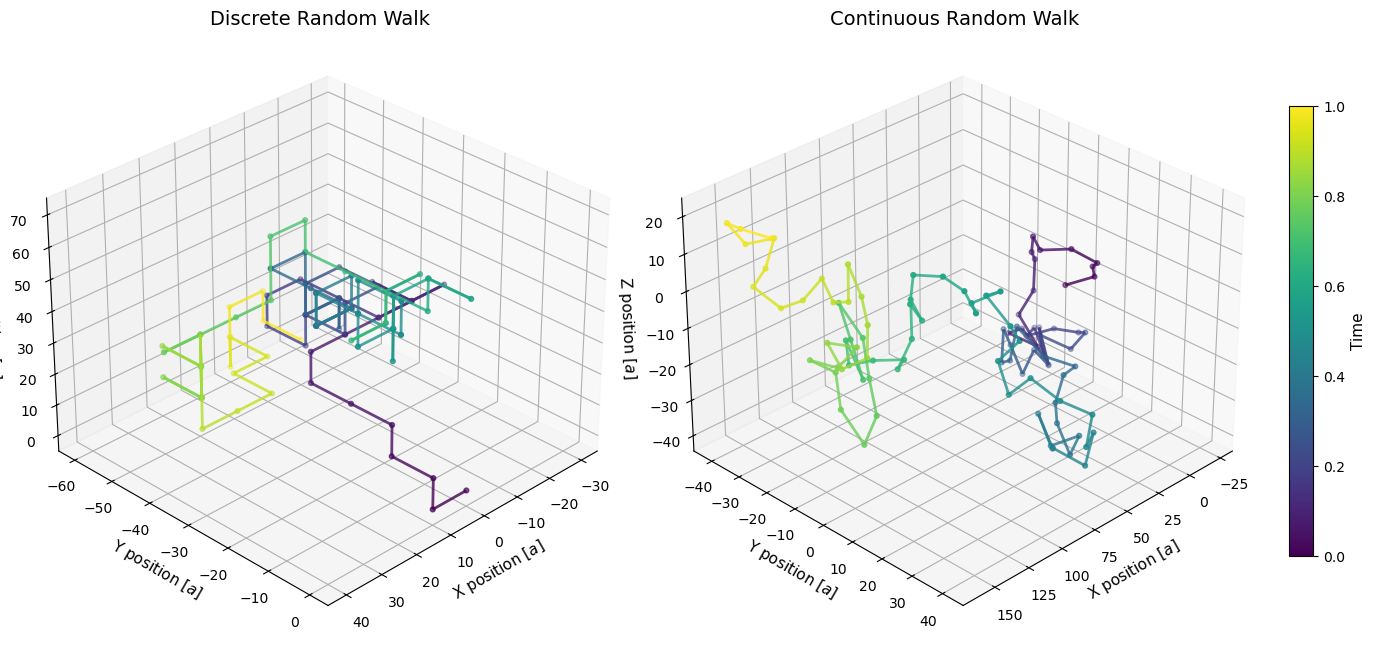

In [12]:
def colored_line(ax, data, cmap='viridis', linewidth=1, alpha=0.6):
    points = data[:, 1:4]
    segments = np.array([points[:-1], points[1:]]).transpose(1, 0, 2)
    colors = np.linspace(0, 1, len(points) - 1)
    lc = Line3DCollection(segments, cmap=cmap, array=colors,
                          linewidth=linewidth, alpha=alpha)
    ax.add_collection3d(lc)
    return lc

data_1s = np.loadtxt("Exercise_2_2/trajectory_discrete.dat")   
data_2p = np.loadtxt("Exercise_2_2/trajectory_continuous.dat")

plt.style.use('default')
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1]) 

cmap = "viridis"
colors_1 = np.linspace(0, 1, len(data_1s))
colors_2 = np.linspace(0, 1, len(data_2p))

ax1 = fig.add_subplot(gs[0], projection='3d')
sc1 = ax1.scatter(data_1s[:, 1], data_1s[:, 2], data_1s[:, 3],
                  c=colors_1, cmap=cmap, s=12)

colored_line(ax1, data_1s, cmap=cmap, linewidth=2, alpha=0.8)

ax1.set_title("Discrete Random Walk", fontsize=14, color='black')
ax1.set_xlabel("X position [$a$]", fontsize=11)
ax1.set_ylabel("Y position [$a$]", fontsize=11)
ax1.set_zlabel("Z position [$a$]", fontsize=11)
ax1.view_init(elev=30, azim=45)

ax2 = fig.add_subplot(gs[1], projection='3d')

sc2 = ax2.scatter(data_2p[:, 1], data_2p[:, 2], data_2p[:, 3],
                  c=colors_2, cmap=cmap, s=12)

colored_line(ax2, data_2p, cmap=cmap, linewidth=2, alpha=0.8)

ax2.set_title("Continuous Random Walk", fontsize=14, color='black')
ax2.set_xlabel("X position [$a$]", fontsize=11)
ax2.set_ylabel("Y position [$a$]", fontsize=11)
ax2.set_zlabel("Z position [$a$]", fontsize=11)
ax2.view_init(elev=30, azim=45)

cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
cbar = fig.colorbar(sc2, cax=cbar_ax)
cbar.set_label("Time", fontsize=11)

plt.subplots_adjust(wspace=0.05, right=0.9)
plt.show()


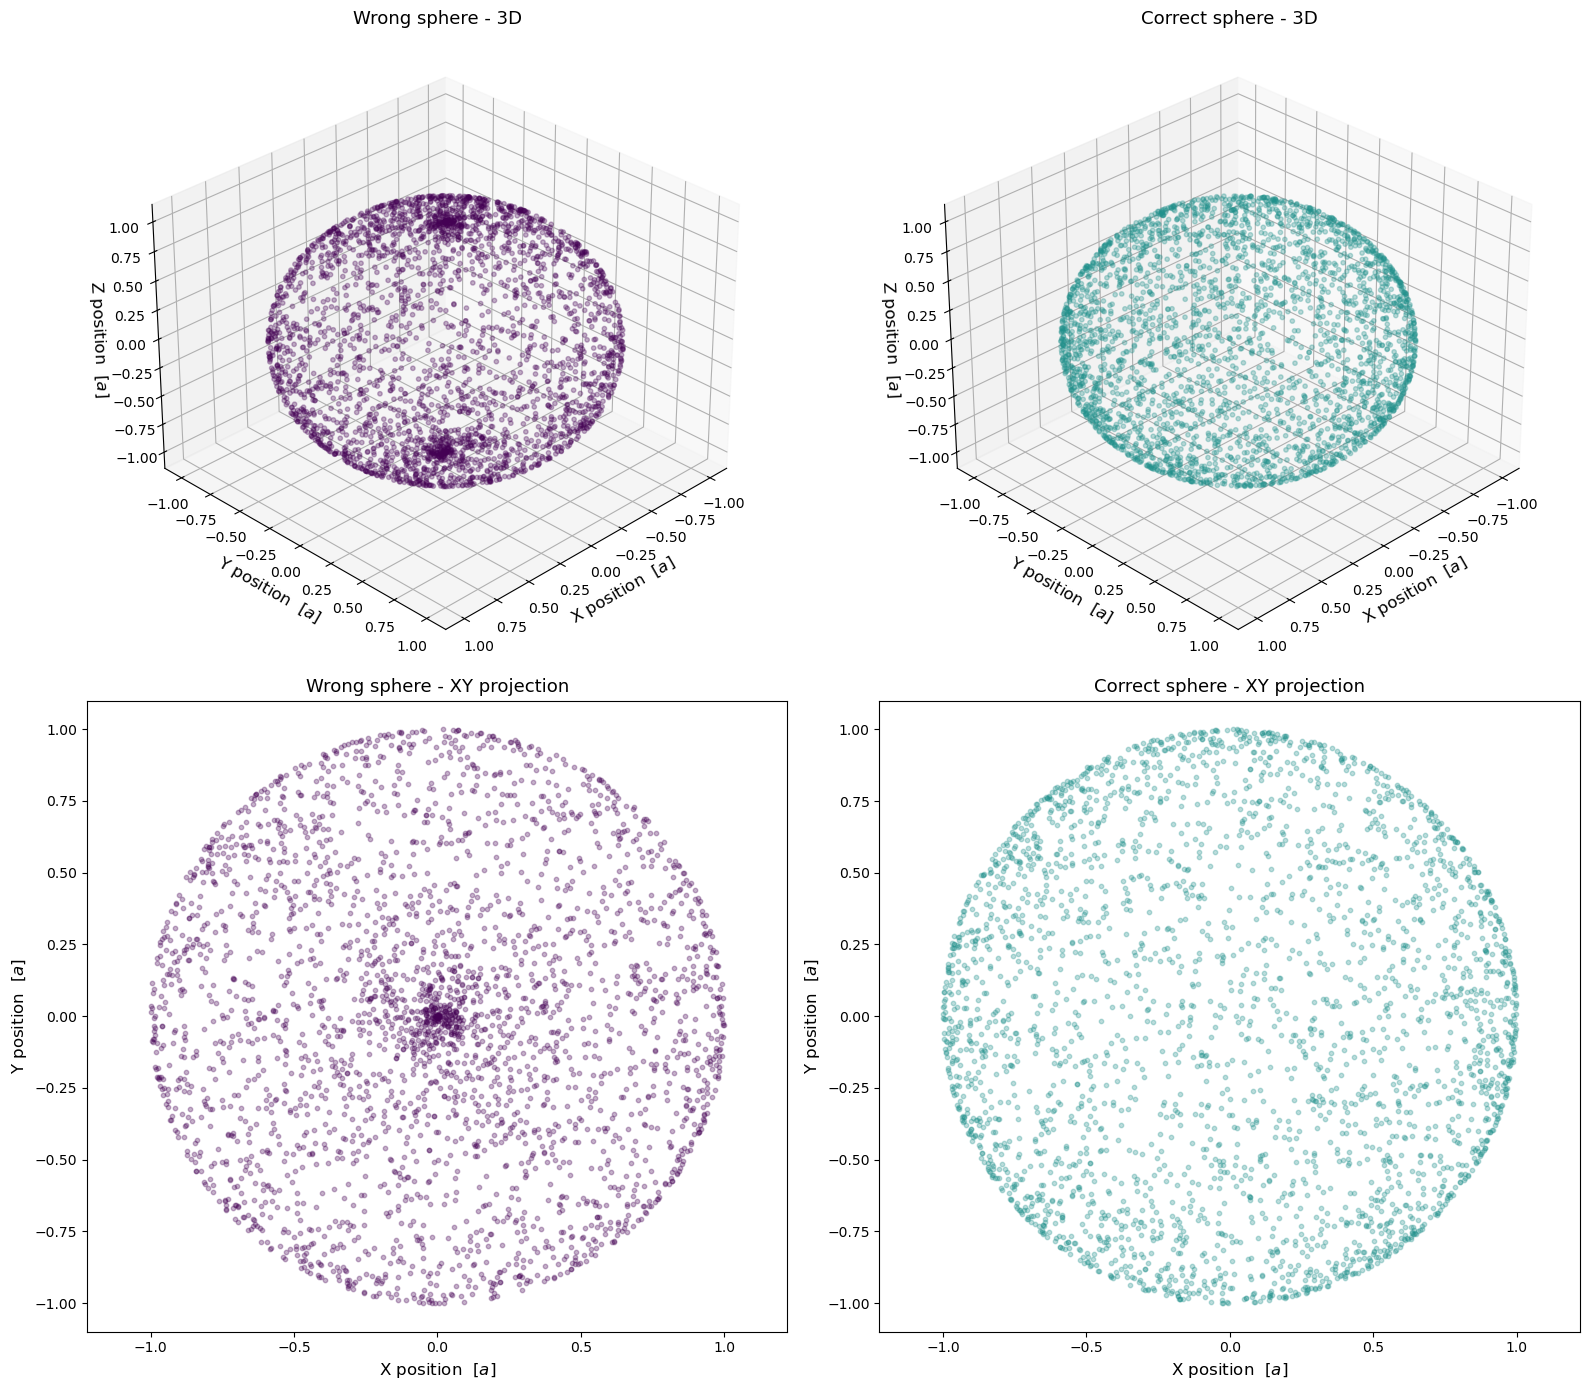

In [11]:
data_1s = np.loadtxt("Exercise_2_2/sphere_wrong.dat")
data_2p = np.loadtxt("Exercise_2_2/sphere_correct.dat")

fig = plt.figure(figsize=(16, 14))

viridis = plt.cm.viridis(np.linspace(0, 1, 5))

plt.style.use('default')

# Subplot 1: Wrong sphere - 3D
ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(data_1s[:, 0], data_1s[:, 1], data_1s[:, 2], color=viridis[0], s=10, alpha=0.3)
ax1.set_title("Wrong sphere - 3D", fontsize=13)
ax1.set_xlabel("X position  [$a$]", fontsize=12)
ax1.set_ylabel("Y position  [$a$]", fontsize=12)
ax1.set_zlabel("Z position  [$a$]", fontsize=12)
ax1.view_init(elev=30, azim=45)

# Subplot 2: Correct sphere - 3D
ax2 = fig.add_subplot(222, projection='3d')
ax2.scatter(data_2p[:, 0], data_2p[:, 1], data_2p[:, 2], color=viridis[2], s=10, alpha=0.3)
ax2.set_title("Correct sphere - 3D", fontsize=13)
ax2.set_xlabel("X position  [$a$]", fontsize=12)
ax2.set_ylabel("Y position  [$a$]", fontsize=12)
ax2.set_zlabel("Z position  [$a$]", fontsize=12)
ax2.view_init(elev=30, azim=45)

# Subplot 3: Wrong sphere - XY projection
ax3 = fig.add_subplot(223)
ax3.scatter(data_1s[:, 0], data_1s[:, 1], color=viridis[0], s=10, alpha=0.3)
ax3.set_title("Wrong sphere - XY projection", fontsize=13)
ax3.set_xlabel("X position  [$a$]", fontsize=12)
ax3.set_ylabel("Y position  [$a$]", fontsize=12)
ax3.axis('equal')

# Subplot 4: Correct sphere - XY projection
ax4 = fig.add_subplot(224)
ax4.scatter(data_2p[:, 0], data_2p[:, 1], color=viridis[2], s=10, alpha=0.3)
ax4.set_title("Correct sphere - XY projection", fontsize=13)
ax4.set_xlabel("X position  [$a$]", fontsize=12)
ax4.set_ylabel("Y position  [$a$]", fontsize=12)
ax4.axis('equal')

plt.tight_layout()
plt.show()
